In [1]:
!pip install --upgrade scikit-learn

In [2]:
#Librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [3]:
# Carga de datos, Modificar ruta segun se requiera
df_original = pd.read_csv('/kaggle/input/datasets/caalsial/dataset-ocurrencia/DATASET_OCURRENCIA.csv')
#Cantidad de observaciones y variables del dataset
df_original.shape

(993516, 22)

## 1. Análisis exploratorio

In [4]:
#Tipo de datos del dataset
df.dtypes

NameError: name 'df' is not defined

In [ ]:
# Se eliminan las columnas que no se requieren para la predicción
columnas_a_eliminar = ['PAR_ID', 'FECHA_HORA', 'ANIO','LATITUD','LONGITUD','CELDA_X','CELDA_Y','TEMPERATURA_2M','PRECIPITACION','FIN_SEMANA']
df = df.drop(columns=columnas_a_eliminar)

In [ ]:
#Nuevas variables

#Hora Pico
df['ES_HORA_PICO'] = df['HORA'].apply(
    lambda x: 1 if (6 <= x <= 9) or (17 <= x <= 20) else 0
)

#Clima adverso
df['CLIMA_ADVERSO'] = ((df['LLUVIA'] > 0) & (df['NUBOSIDAD'] > 80)).astype(int)

In [ ]:
df.head(5)

In [ ]:
#Estadísticas descriptivas de las variables numéricas
df.describe()

In [ ]:
#Cantidad de datos vacíos del dataset
df.isna().sum()

In [ ]:
#Porcentaje de observaciones por ocurrencia de accidente
df['OCURRIO_ACCIDENTE'].value_counts(normalize=True)

In [ ]:
# Visualización de distribuciones de variables numéricas
numeric_cols = df.select_dtypes(include=['number']).columns.tolist() # Seleccionar columnas numéricas

# Configurar el tamaño de la figura según la cantidad de variables numéricas
num_cols = len(numeric_cols) # de variables numéricas
cols_per_row = 3
rows = (num_cols + cols_per_row - 1) // cols_per_row # Calcular número de filas necesarias

# Crear subplots para cada variable numérica
plt.figure(figsize=(cols_per_row * 5, rows * 4)) # Ajustar tamaño de la figura
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols_per_row, i)
    sns.histplot(df[col], bins=30, kde=True, color='teal', edgecolor='black')
    plt.title(col, fontsize=11, weight='bold')
    plt.xlabel("")
    plt.ylabel("")
plt.tight_layout() # Ajustar el diseño para evitar solapamientos
plt.show()

In [ ]:
#Matriz de correlación
corr=df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', annot_kws={'size': 9})
plt.title("Mapa de calor de correlación")
plt.tight_layout()
plt.show()

In [ ]:
accidentes_por_mes = df.groupby('MES')['OCURRIO_ACCIDENTE'].sum()

# Crear la figura
plt.figure(figsize=(10, 6))
accidentes_por_mes.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Cantidad de Accidentes por Mes', fontsize=14, pad=15)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Total de Accidentes', fontsize=12)
plt.xticks(rotation=0) 
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
accidentes_por_dia = df.groupby('DIA_SEMANA')['OCURRIO_ACCIDENTE'].sum()

# Crear la figura
plt.figure(figsize=(10, 6))
accidentes_por_dia.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Cantidad de Accidentes por Dia', fontsize=14, pad=15)
plt.xlabel('Dia', fontsize=12)
plt.ylabel('Total de Accidentes', fontsize=12)
plt.xticks(rotation=0) 
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8, 6))
sns.stripplot(x='OCURRIO_ACCIDENTE', y='LLUVIA', data=df, 
              jitter=True, alpha=0.3, color='teal')

plt.title('Dispersión de Lluvia vs. Ocurrencia de Accidentes', fontsize=14)
plt.xlabel('Ocurrió Accidente', fontsize=12)
plt.ylabel('Cantidad de Lluvia', fontsize=12)

plt.show()

## 1.1 Clustering

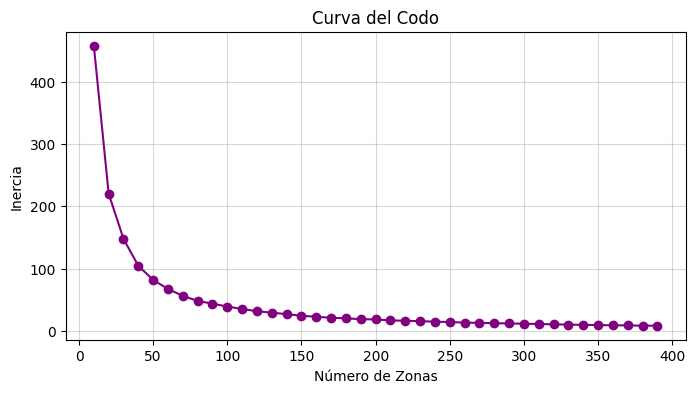

In [60]:
from sklearn.cluster import MiniBatchKMeans
#Curva del codo para k medias
coordenadas = df_original[['LATITUD', 'LONGITUD']]
inercias = []
rango_k = range(10, 400, 10)

for k in rango_k:
    kmeans_temp = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=10000, n_init=3)
    kmeans_temp.fit(coordenadas)
    inercias.append(kmeans_temp.inertia_)

# Mostrar la curva
plt.figure(figsize=(8, 4))
plt.plot(rango_k, inercias, marker='o', color='purple')
plt.title('Curva del Codo')
plt.xlabel('Número de Zonas')
plt.ylabel('Inercia')
plt.grid(True, alpha=0.5)
plt.show()

In [61]:
#K-medias con las zonas definidas según el codo
kmeans = MiniBatchKMeans(n_clusters=150, random_state=42, batch_size=10000, n_init=3)
df_original['ZONA_CIUDAD'] = kmeans.fit_predict(coordenadas)

In [62]:
from itertools import product
# Se guardan los datos de los accidentes que realmenet ocurrieron y se agrupan
df_reales = df_original[df_original['OCURRIO_ACCIDENTE'] == 1].copy()
agregaciones = {
    'OCURRIO_ACCIDENTE': 'max',  # Si hubo al menos un accidente, la etiqueta es 1
    'SENSACION_TERMICA': 'mean', 
    'LLUVIA': 'mean', 
    'NUBOSIDAD': 'mean', 
    'VELOCIDAD_VIENTO_10M': 'mean'
}
df_agrupado = df_reales.groupby(['ZONA_CIUDAD', 'MES', 'DIA_SEMANA', 'HORA']).agg(agregaciones).reset_index()


#Se crea una cuadricula para todas las combinacioens posibles de zona, mes, dia hora
cuadricula = pd.DataFrame(
    list(product(range(150), range(1, 13), range(0, 7), range(0, 24))), 
    columns=['ZONA_CIUDAD', 'MES', 'DIA_SEMANA', 'HORA']
)


# Se asigna OCURRIO_ACCIDENTE=0 para todas las combinaciones que no tienen accidentes
df = pd.merge(cuadricula, df_agrupado, on=['ZONA_CIUDAD', 'MES', 'DIA_SEMANA', 'HORA'], how='left')
df['OCURRIO_ACCIDENTE'] = df['OCURRIO_ACCIDENTE'].fillna(0)

# Se rellena el clima con promedios históricos para las horas sin accidente (NOTA: Se debe completar con el clima real)
clima_prom = df_original.groupby(['MES', 'HORA'])[['SENSACION_TERMICA', 'LLUVIA', 'NUBOSIDAD', 'VELOCIDAD_VIENTO_10M']].mean().reset_index()
df = pd.merge(df, clima_prom, on=['MES', 'HORA'], how='left', suffixes=('', '_prom'))
for col in ['SENSACION_TERMICA', 'LLUVIA', 'NUBOSIDAD', 'VELOCIDAD_VIENTO_10M']:
    df[col] = df[col].fillna(df[col + '_prom']).drop(columns=[col + '_prom'])

In [63]:
# 1. Agrupar por zona y agregar accidentes
accidentes_por_zona = df.groupby('ZONA_CIUDAD')['OCURRIO_ACCIDENTE'].sum().reset_index()
accidentes_por_zona.rename(columns={'OCURRIO_ACCIDENTE': 'TOTAL_ACCIDENTES'}, inplace=True)

total_zonas = len(accidentes_por_zona)
promedio_accidentes_zona = accidentes_por_zona['TOTAL_ACCIDENTES'].mean()
zona_mas_peligrosa = accidentes_por_zona.loc[accidentes_por_zona['TOTAL_ACCIDENTES'].idxmax()]

print(f"Cantidad total de zonas analizadas : {total_zonas}")
print(f"Promedio de accidentes por zona    : {promedio_accidentes_zona:.1f} accidentes")
print(f"Zona con más accidentes            : Zona {int(zona_mas_peligrosa['ZONA_CIUDAD'])} (con {int(zona_mas_peligrosa['TOTAL_ACCIDENTES'])} accidentes registrados)")

Cantidad total de zonas analizadas : 150
Promedio de accidentes por zona    : 1386.5 accidentes
Zona con más accidentes            : Zona 48 (con 1785 accidentes registrados)


In [45]:
df.columns

Index(['ZONA_CIUDAD', 'MES', 'DIA_SEMANA', 'HORA', 'OCURRIO_ACCIDENTE',
       'SENSACION_TERMICA', 'LLUVIA', 'NUBOSIDAD', 'VELOCIDAD_VIENTO_10M',
       'SENSACION_TERMICA_prom', 'LLUVIA_prom', 'NUBOSIDAD_prom',
       'VELOCIDAD_VIENTO_10M_prom'],
      dtype='object')

In [64]:
#Se quitan las columnas que no se requieren
columnas_predictoras = [
    'MES', 'DIA_SEMANA', 'HORA',
    'ZONA_CIUDAD'
]



In [65]:
df.describe()

,ZONA_CIUDAD,MES,DIA_SEMANA,HORA,OCURRIO_ACCIDENTE,SENSACION_TERMICA,LLUVIA,NUBOSIDAD,VELOCIDAD_VIENTO_10M,SENSACION_TERMICA_prom,LLUVIA_prom,NUBOSIDAD_prom,VELOCIDAD_VIENTO_10M_prom
count,302400.00000,302400.000000,302400.000000,302400.000000,302400.000000,302400.000000,302400.000000,302400.000000,302400.000000,302400.000000,302400.000000,302400.000000,302400.000000
mean,74.50000,6.500000,3.000000,11.500000,0.687745,12.823884,0.140740,84.896000,6.345772,12.818443,0.138290,84.969086,6.362246
std,43.30038,3.452058,2.000003,6.922198,0.463414,3.331889,0.332740,14.996247,3.312717,2.928380,0.123582,6.161429,2.285292
min,0.00000,1.000000,0.000000,0.000000,0.000000,-2.200000,0.000000,0.000000,0.000000,8.456146,0.008786,66.917714,3.316283
25%,37.00000,3.750000,1.000000,5.750000,0.000000,10.161378,0.000000,79.666667,4.271613,10.171007,0.050273,80.497926,4.595834
50%,74.50000,6.500000,3.000000,11.500000,1.000000,12.322337,0.050000,88.521696,5.450000,12.253242,0.102459,85.199673,5.627264
75%,112.00000,9.250000,5.000000,17.250000,1.000000,15.466667,0.137368,95.333333,7.800000,15.404536,0.179330,89.852022,7.683584
max,149.00000,12.000000,6.000000,23.000000,1.000000,26.300000,11.100000,100.000000,29.400000,18.669408,0.648679,96.559458,13.037113


In [66]:
#Porcentaje de observaciones por ocurrencia de accidente
df['OCURRIO_ACCIDENTE'].value_counts(normalize=True)

OCURRIO_ACCIDENTE
1.0    0.687745
0.0    0.312255
Name: proportion, dtype: float64

In [67]:
df.shape

(302400, 13)

In [74]:

import folium

from folium.plugins import HeatMap

In [75]:


# 1. Agrupamos los accidentes reales por coordenadas y cluster
df_puntos = df_original[df_original['OCURRIO_ACCIDENTE'] == 1].copy()

# 2. Calculamos el centro geográfico de cada zona
centroides = df_puntos.groupby('ZONA_CIUDAD').agg(
    LATITUD=('LATITUD', 'mean'),
    LONGITUD=('LONGITUD', 'mean'),
    TOTAL_ACCIDENTES=('OCURRIO_ACCIDENTE', 'count')
).reset_index()

# Centrar el mapa en el punto medio de Bogotá
lat_centro = centroides['LATITUD'].mean()
lon_centro = centroides['LONGITUD'].mean()

mapa_zonas = folium.Map(location=[lat_centro, lon_centro], zoom_start=11, tiles='CartoDB positron')

# Agregar un círculo por cada cluster/zona
for _, fila in centroides.iterrows():
    folium.CircleMarker(
        location=[fila['LATITUD'], fila['LONGITUD']],
        radius=6,
        popup=f"<b>Zona:</b> {int(fila['ZONA_CIUDAD'])}<br><b>Accidentes:</b> {int(fila['TOTAL_ACCIDENTES'])}",
        color='crimson' if fila['TOTAL_ACCIDENTES'] > centroides['TOTAL_ACCIDENTES'].median() else 'blue',
        fill=True,
        fill_opacity=0.6
    ).add_to(mapa_zonas)

# Mostrar el mapa en el Notebook
mapa_zonas

In [76]:
mapa_calor = folium.Map(location=[lat_centro, lon_centro], zoom_start=11, tiles='CartoDB positron')

# Preparar datos de densidad: [Latitud, Longitud, Peso/Accidentes]
datos_calor = centroides[['LATITUD', 'LONGITUD', 'TOTAL_ACCIDENTES']].values.tolist()

# Añadir capa de calor
HeatMap(datos_calor, radius=15, blur=10, max_zoom=13).add_to(mapa_calor)

# Mostrar el mapa de calor
mapa_calor

## 2. Conjunto de datos de entrenamiento y prueba

In [68]:
from sklearn.model_selection import train_test_split

# Se separan las variables
X = df[columnas_predictoras]
y = df['OCURRIO_ACCIDENTE']

#  Se dividen los datos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20,
    random_state=42
)

print(f"Tamaño de X_train: {X_train.shape}")
print(f"Tamaño de X_test: {X_test.shape}")

Tamaño de X_train: (241920, 4)
Tamaño de X_test: (60480, 4)


## 3. Entrenamiento y prueba de modelos de clasificación

### 3.1 Regresión logística

In [56]:
#Librerias de sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (roc_auc_score, f1_score, balanced_accuracy_score,precision_score, recall_score, log_loss)

In [57]:
#Se escalan los dato
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [58]:
# Se crea el modelo base de regresión logística
log_reg_base= LogisticRegression(max_iter=1000, random_state=42)

In [59]:
#Calibración de hiperparámetros
parametros_lr = {
'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'l1_ratio': [0.0, 1.0, 0.25, 0.5, 0.75], 
    'solver': ['saga']
}

#Grid search para encontrar el mejor modelo
grid_search_lr = GridSearchCV(
    estimator=log_reg_base,
    param_grid=parametros_lr,
    cv=5,                 # Validación cruzada de 5 particiones
    scoring='roc_auc',
    n_jobs=-1
)

#Entrenamiento de los modelos

inicio_tiempo = time.time()

grid_search_lr.fit(X_train_scaled, y_train)

fin_tiempo = time.time()
tiempo_total = fin_tiempo - inicio_tiempo
minutos = int(tiempo_total // 60)
segundos = int(tiempo_total % 60)

print(f"Duración del entrenamiento {minutos} minutos y {segundos} segundos")

mejor_lr = grid_search_lr.best_estimator_

print(f"Mejores parámetros encontrados: {grid_search_lr.best_params_}\n")

Duración del entrenamiento 8 minutos y 59 segundos
Mejores parámetros encontrados: {'C': 1, 'l1_ratio': 1.0, 'solver': 'saga'}



In [ ]:
#Predicciones
y_pred_lr = mejor_lr.predict(X_test_scaled)
y_prob_lr = mejor_lr.predict_proba(X_test_scaled)[:, 1]

In [ ]:
#Se calculan las métricas
metricas = {
    "ROC-AUC": roc_auc_score(y_test, y_prob_lr),
    "F1 Score": f1_score(y_test, y_pred_lr),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr),
    "Recall (Sensibilidad)": recall_score(y_test, y_pred_lr),
    "Log Loss": log_loss(y_test, y_prob_lr)
}

print("--- Resultados del Modelo: Regresión Logística Calibrada ---")
for metrica, valor in metricas.items():
    print(f"{metrica:<22}: {valor:.4f}")

### 3.2 Random Forest Classifier

In [ ]:
#Librerias de sklearn
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (roc_auc_score, f1_score, balanced_accuracy_score,precision_score, recall_score, log_loss)
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Se crea el modelo base de RF Classifier
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

In [ ]:
#Calibración de hiperparámetros
parametros_rf = {
    'n_estimators': [50, 100, 150],      
    'max_depth': [5, 10],          
    'min_samples_split': [2, 5] 
}

#Grid search para encontrar el mejor modelo
grid_search_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=parametros_rf,
    cv=5,                 # Validación cruzada de 5 particiones
    scoring='roc_auc',
    n_jobs=-1
)

#Entrenamiento de los modelos

inicio_tiempo = time.time()

grid_search_rf.fit(X_train, y_train)

fin_tiempo = time.time()
tiempo_total = fin_tiempo - inicio_tiempo
minutos = int(tiempo_total // 60)
segundos = int(tiempo_total % 60)

print(f"Duración del entrenamiento {minutos} minutos y {segundos} segundos")

mejor_rf = grid_search_rf.best_estimator_

print(f"Mejores parámetros encontrados: {grid_search_rf.best_params_}\n")

In [ ]:
# Se encuentran las variables de mayor importancia
importancias = mejor_rf.feature_importances_

df_importancias = pd.DataFrame({'Variable': X_train.columns, 'Importancia': importancias})
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False)

df_importancias

In [ ]:
#Predicciones
y_pred_lr_rf = mejor_rf.predict(X_test)
y_prob_lr_rf = mejor_rf.predict_proba(X_test)[:, 1]

In [ ]:
#Se calculan las métricas
metricas_rf = {
    "ROC-AUC": roc_auc_score(y_test, y_prob_lr_rf),
    "F1 Score": f1_score(y_test, y_pred_lr_rf),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_lr_rf),
    "Precision": precision_score(y_test, y_pred_lr_rf),
    "Recall (Sensibilidad)": recall_score(y_test, y_pred_lr_rf),
    "Log Loss": log_loss(y_test, y_prob_lr_rf)
}

print("--- Resultados de Random Forest (Optimizado, Sin Calibrar) ---")
for metrica, valor in metricas_rf.items():
    print(f"{metrica:<22}: {valor:.4f}")

### 3.3 XGBoost Classifier

In [12]:
!pip install --upgrade xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 MB 32.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.4/252.4 MB 7.2 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: xgboost
    Found existing installation: xgboost 3.2.0
    Uninstalling xgboost-3.2.0:
      Successfully uninstalled xgboost-3.2.0


In [13]:
# Librerías
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (roc_auc_score, f1_score, balanced_accuracy_score,precision_score, recall_score, log_loss)
from xgboost import XGBClassifier

In [69]:
#Modelo baso de XGB Classifier
xgb_base = XGBClassifier(random_state=42, n_jobs=-1, device='cuda')


In [70]:
# Calibración de hiperparámetros
parametros_xgb = {
    'n_estimators': [50, 100, 150],      
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.2] 
}

#Grid search para encontrar el mejor modelo
grid_search_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=parametros_xgb,
    cv=5,                 # Validación cruzada de 5 particiones
    scoring='precision',
    n_jobs=-1
)

# Entrenamiento de los modelos
inicio_tiempo = time.time()

grid_search_xgb.fit(X_train, y_train)

fin_tiempo = time.time()
tiempo_total = fin_tiempo - inicio_tiempo
minutos = int(tiempo_total // 60)
segundos = int(tiempo_total % 60)

print(f"Duración del entrenamiento {minutos} minutos y {segundos} segundos")

mejor_xgb = grid_search_xgb.best_estimator_

print(f"Mejores parámetros encontrados: {grid_search_xgb.best_params_}\n")

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:569: UserWarning: [17:19:41] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
/usr/local/lib/python3.12/dist-packages/xgboost/core.py:569: UserWarning: [17:19:41] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the devic

Duración del entrenamiento 1 minutos y 2 segundos
Mejores parámetros encontrados: {'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 150}



In [71]:
#Predicciones
y_pred_xgb = mejor_xgb.predict(X_test)
y_prob_xgb = mejor_xgb.predict_proba(X_test)[:, 1]

In [72]:
#Metricas
metricas_xgb = {
    "ROC-AUC": roc_auc_score(y_test, y_prob_xgb),
    "F1 Score": f1_score(y_test, y_pred_xgb),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_xgb),
    "Precision": precision_score(y_test, y_pred_xgb),
    "Recall (Sensibilidad)": recall_score(y_test, y_pred_xgb),
    "Log Loss": log_loss(y_test, y_prob_xgb)
}

print("--- Resultados de XGBoost ---")
for metrica, valor in metricas_xgb.items():
    print(f"{metrica:<22}: {valor:.4f}")

--- Resultados de XGBoost ---
ROC-AUC               : 0.8232
F1 Score              : 0.8503
Balanced Accuracy     : 0.7113
Precision             : 0.8069
Recall (Sensibilidad) : 0.8985
Log Loss              : 0.4662


### 3.5 Comparación de modelos

In [ ]:
df_comparacion = pd.DataFrame({
    'Regresión Logística': metricas,
    'Random Forest': metricas_rf,
    'XGBoost': metricas_xgb
})


print("--- Comparación de Modelos ---")
display(df_comparacion.round(4))